<a href="https://colab.research.google.com/github/Miguel-Cabas/Laboratorio/blob/main/Lab11_Visualizacion_de_Datos_Miguel_Cabas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 11 — Introducción a la visualización de los datos
**Ejercicio 1:** Interpretación de visualizaciones con respecto a valores atípicos (Bike Sales)
**Ejercicio 2:** Visualizaciones de escenarios reales

El archivo `Bike_Sales_Outlier_Lab.xlsx` se carga directamente desde GitHub (raw).

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Ejercicio de práctica 1 — Interpretación de visualizaciones con valores atípicos

### Paso 1 — Abrir el conjunto de datos



In [17]:
# Cargar el archivo Excel directamente desde GitHub (raw)
url = 'https://raw.githubusercontent.com/Miguel-Cabas/Laboratorio/main/Bike_Sales_Outlier_Lab.xlsx'

data = pd.read_excel(url, sheet_name='Bike Sales')

# Quitar espacios en los nombres de columnas
data.columns = data.columns.str.strip()

print(data.columns)
data.head()

Index(['Sales_Order #', 'Date', 'Day', 'Month', 'Year', 'Customer_Age',
       'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product_Description', 'Order_Quantity', 'Unit_Cost',
       'Unit_Price', 'Profit', 'Cost', 'Revenue'],
      dtype='object')


,Sales_Order #,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product_Description,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,261696,2021-12-01,1,December,2021,39,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",4,1252,2295,4172,5008,9180
1,261695,2021-12-01,1,December,2021,44,Adults (35-64),M,United Kingdom,England,Bikes,Mountain Bikes,"Mountain-200 Silver, 42",1,1266,2320,1054,1266,2320
2,261697,2021-12-02,2,December,2021,37,Adults (35-64),M,United States,California,Bikes,Mountain Bikes,"Mountain-400-W Silver, 46",2,420,769,698,840,1538
3,261698,2021-12-02,2,December,2021,31,Young Adults (25-34),F,Australia,New South Wales,Bikes,Mountain Bikes,"Mountain-400-W Silver, 42",1,420,769,349,420,769
4,261699,2021-12-03,3,December,2021,37,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",2,1252,2295,2086,2504,4590


### Paso 2 — Tabla dinámica (equivalente en Python)
En Excel se usa una tabla dinámica con los campos `Date` y `Order_Quantity`.
En pandas el equivalente es un `groupby()` sobre la fecha sumando la cantidad de pedido.

In [18]:
# Tabla dinámica: suma de Order_Quantity por fecha
tabla_dinamica = data.groupby('Date')['Order_Quantity'].sum().reset_index()
tabla_dinamica.columns = ['Date', 'Sum_of_Order_Quantity']

print(f'Total general: {tabla_dinamica["Sum_of_Order_Quantity"].sum()}')
tabla_dinamica

Total general: 197


,Date,Sum_of_Order_Quantity
0,2021-12-01,5
1,2021-12-02,3
2,2021-12-03,4
3,2021-12-04,4
4,2021-12-05,10
5,2021-12-06,6
6,2021-12-07,6
7,2021-12-08,11
8,2021-12-09,3
9,2021-12-10,8


### Paso 3 — Ordenar los datos para encontrar valores atípicos
Una forma de identificar valores atípicos es simplemente ordenar los datos de mayor a menor.

In [19]:
# Ordenar de mayor a menor (equivale a Ordenar y filtrar > Ordenar descendente)
ordenado = tabla_dinamica.sort_values('Sum_of_Order_Quantity', ascending=False).reset_index(drop=True)
ordenado.head(10)

,Date,Sum_of_Order_Quantity
0,2021-12-19,43
1,2021-12-18,19
2,2021-12-20,13
3,2021-12-12,12
4,2021-12-08,11
5,2021-12-05,10
6,2021-12-22,10
7,2021-12-10,8
8,2021-12-11,8
9,2021-12-07,6


In [20]:
# RESPUESTAS DEL PASO 3
fecha_max = ordenado.loc[0, 'Date']
cantidad_max = ordenado.loc[0, 'Sum_of_Order_Quantity']

print(f'¿En qué fecha de diciembre se registró la mayor cantidad de ventas?')
print(f'  -> {fecha_max.strftime("%d/%m/%Y")}\n')
print(f'¿Cuál fue la cantidad de ventas?')
print(f'  -> {cantidad_max} unidades')

¿En qué fecha de diciembre se registró la mayor cantidad de ventas?
  -> 19/12/2021

¿Cuál fue la cantidad de ventas?
  -> 43 unidades


In [21]:
# ¿Qué entrada (número de pedido) es la más responsable del valor atípico?
detalle_19dic = data[data['Date'] == fecha_max].sort_values('Order_Quantity', ascending=False)

print('Registros del 19 de diciembre ordenados por Order_Quantity:\n')
display(detalle_19dic[['Sales_Order #', 'Date', 'Product_Description', 'Order_Quantity', 'Revenue']])

pedido_culpable = detalle_19dic.iloc[0]
print(f'\n-> El pedido más responsable del valor atípico es: {pedido_culpable["Sales_Order #"]}')
print(f'   con una cantidad de {pedido_culpable["Order_Quantity"]} unidades.')

Registros del 19 de diciembre ordenados por Order_Quantity:



,Sales_Order #,Date,Product_Description,Order_Quantity,Revenue
70,261765,2021-12-19,"Mountain-200 Silver, 38",11,25520
61,261756,2021-12-19,"Mountain-200 Silver, 46",4,9280
62,261757,2021-12-19,"Mountain-500 Black, 44",4,2160
63,261758,2021-12-19,"Mountain-200 Black, 38",4,9180
65,261760,2021-12-19,"Mountain-200 Black, 38",4,9180
64,261759,2021-12-19,"Mountain-100 Black, 48",4,13500
66,261761,2021-12-19,"Mountain-200 Black, 46",4,9180
67,261762,2021-12-19,"Mountain-200 Black, 46",4,9180
68,261763,2021-12-19,"Mountain-500 Black, 40",2,1080
69,261764,2021-12-19,"Mountain-200 Black, 46",2,4590



-> El pedido más responsable del valor atípico es: 261765
   con una cantidad de 11 unidades.


### Paso 4 — Gráfico de dispersión para encontrar valores atípicos
Se ordena por fecha en orden ascendente y se grafica `Sum_of_Order_Quantity` para visualizar el valor atípico.

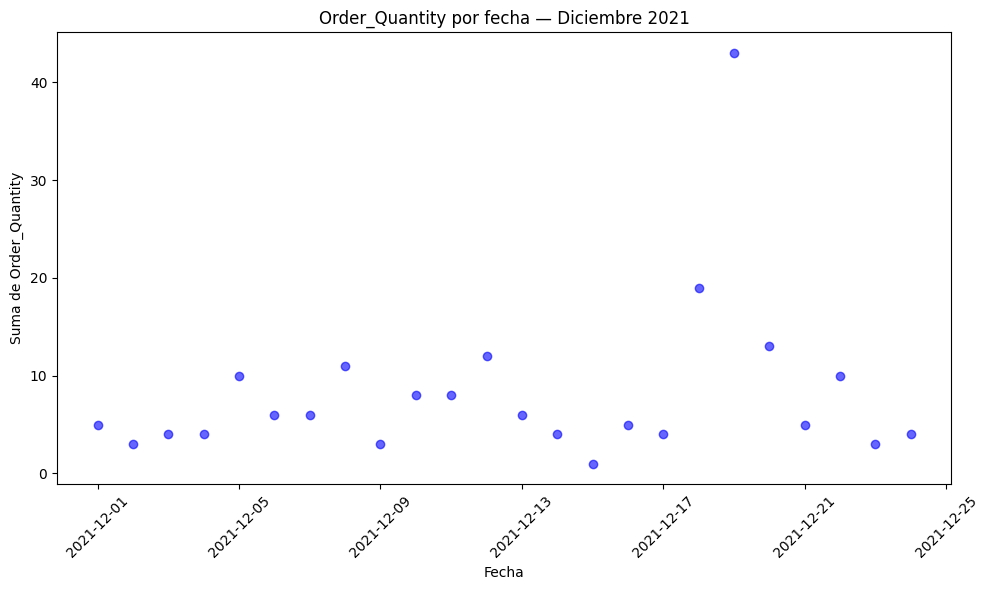

In [22]:
# Ordenar por fecha ascendente para el gráfico de dispersión (equivale al Paso 4 en Excel)
por_fecha = tabla_dinamica.sort_values('Date', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.scatter(por_fecha['Date'], por_fecha['Sum_of_Order_Quantity'], color='b', alpha=0.6)

plt.title('Order_Quantity por fecha — Diciembre 2021')
plt.xlabel('Fecha')
plt.ylabel('Suma de Order_Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('paso4_scatter_fecha.png', dpi=130)
plt.show()

**Interpretación:** el punto correspondiente al 19 de diciembre se destaca claramente del resto de los datos (43 unidades vs. un rango normal de 1 a 19), confirmando visualmente que es un valor atípico.

### Paso 5 — Funciones GRANDE y PEQUEÑO (equivalente en Python)
En Excel se usan `=GRANDE()` y `=PEQUEÑO()`. En pandas el equivalente son `nlargest()` y `nsmallest()`.

In [23]:
# Equivalente a =GRANDE($E$4:$E$27,1) -> valor más alto
valor_mas_alto = tabla_dinamica['Sum_of_Order_Quantity'].nlargest(1).values[0]
print(f'Valor más alto (GRANDE): {valor_mas_alto}')

# Equivalente a =LARGE($E$4:$E$27, ROW($1:5)) -> 5 valores más altos
cinco_mas_altos = tabla_dinamica.nlargest(5, 'Sum_of_Order_Quantity')
print('\n5 valores más altos:')
display(cinco_mas_altos)

Valor más alto (GRANDE): 43

5 valores más altos:


,Date,Sum_of_Order_Quantity
18,2021-12-19,43
17,2021-12-18,19
19,2021-12-20,13
11,2021-12-12,12
7,2021-12-08,11


In [24]:
# Equivalente a =PEQUEÑO($E$4:$E$27, FILA($1:6)) -> 6 valores más bajos
seis_mas_bajos = tabla_dinamica.nsmallest(6, 'Sum_of_Order_Quantity')
print('6 valores más bajos:')
display(seis_mas_bajos)

6 valores más bajos:


,Date,Sum_of_Order_Quantity
14,2021-12-15,1
1,2021-12-02,3
8,2021-12-09,3
22,2021-12-23,3
2,2021-12-03,4
3,2021-12-04,4


In [25]:
# Ejemplo de las dos formas de tratar el valor atípico (sin sobrescribir los datos originales)

# 1. Eliminarlo
data_sin_outlier = data[data['Sales_Order #'] != pedido_culpable['Sales_Order #']].copy()
print(f'Filas originales: {len(data)} -> Filas sin el pedido atípico: {len(data_sin_outlier)}')

# 2. Normalizarlo (ajustar solo ese pedido a un valor justo por encima del máximo normal)
data_normalizado = data.copy()
idx = data_normalizado[data_normalizado['Sales_Order #'] == pedido_culpable['Sales_Order #']].index
data_normalizado.loc[idx, 'Order_Quantity'] = 20
print(f'Cantidad normalizada para el pedido {pedido_culpable["Sales_Order #"]}: 20 (antes: {pedido_culpable["Order_Quantity"]})')

Filas originales: 88 -> Filas sin el pedido atípico: 87
Cantidad normalizada para el pedido 261765: 20 (antes: 11)


**Reflexión — ¿qué factores determinan si un valor atípico debe considerarse en el análisis final?**
- Causa del dato: ¿error de captura/medición o venta real (pedido corporativo, promoción)?
- Impacto en las métricas: ¿distorsiona mucho el promedio o la varianza?
- Tamaño de la muestra: en datasets pequeños un atípico pesa más.
- Objetivo del análisis: si buscas tendencia general quizá se excluye; si buscas eventos excepcionales, el atípico es el hallazgo.
- Recurrencia: ¿es un caso aislado o un patrón que se repite?
- Documentación: dejar registro de qué se hizo con el dato y por qué.

### Análisis adicional (Desarrollo en Python de la guía) — Cantidad de órdenes vs. Ingresos
Este es el gráfico de dispersión adicional que propone la guía para relacionar `Order_Quantity` con `Revenue`.

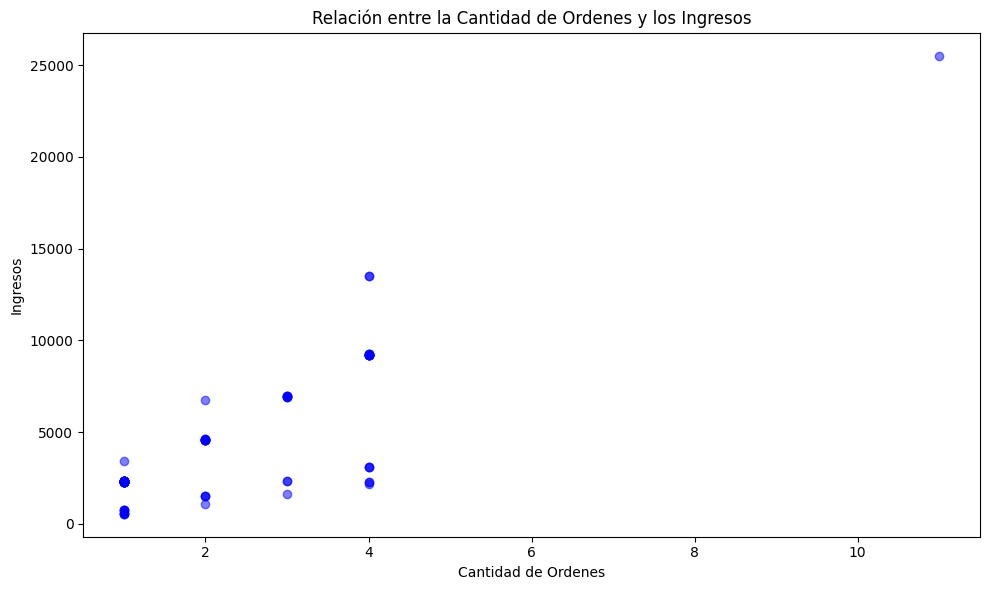

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(data['Order_Quantity'], data['Revenue'], color='b', alpha=0.5)

plt.title('Relación entre la Cantidad de Ordenes y los Ingresos')
plt.xlabel('Cantidad de Ordenes')
plt.ylabel('Ingresos')

plt.tight_layout()
plt.savefig('ej1_scatter_bikesales.png', dpi=130)
plt.show()

**Interpretación:** a mayor cantidad de órdenes, el ingreso tiende a aumentar, pero no de forma proporcional: hay pedidos pequeños con ingresos altos (productos de mayor valor) y un punto claramente atípico con ingresos excepcionalmente altos y pocas unidades — posible venta premium que vale la pena investigar antes de decidir si se excluye o se conserva en el análisis.

## Ejercicio de práctica 2 — Escenarios de práctica

### 2.1 Comparación de calificaciones de estudiantes en diferentes asignaturas

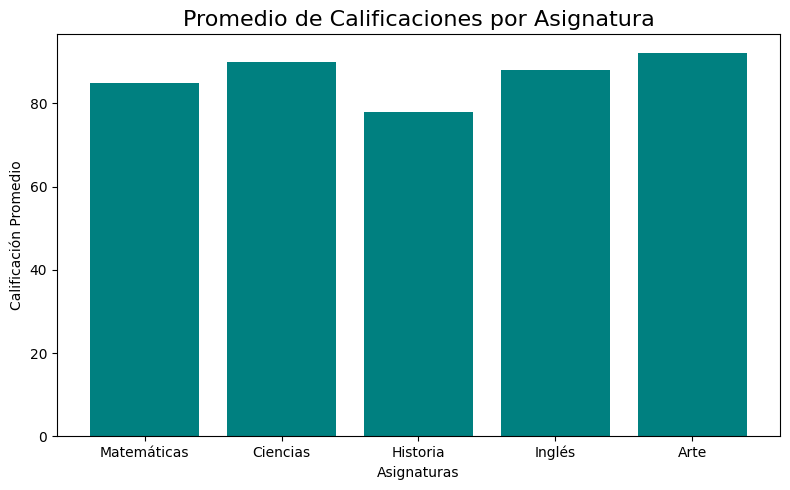

In [27]:
asignaturas = ['Matemáticas', 'Ciencias', 'Historia', 'Inglés', 'Arte']
calificaciones = [85, 90, 78, 88, 92]

plt.figure(figsize=(8, 5))
plt.bar(asignaturas, calificaciones, color='teal')

plt.title('Promedio de Calificaciones por Asignatura', fontsize=16)
plt.xlabel('Asignaturas')
plt.ylabel('Calificación Promedio')

plt.tight_layout()
plt.savefig('ej2_1_calificaciones.png', dpi=130)
plt.show()

**Interpretación:** los estudiantes tienen mejor desempeño en Arte (92) y Ciencias (90), mientras que Historia (78) es la asignatura con menor promedio — posible foco de refuerzo.

### 2.2 Comparación del tiempo de carga de diferentes páginas web

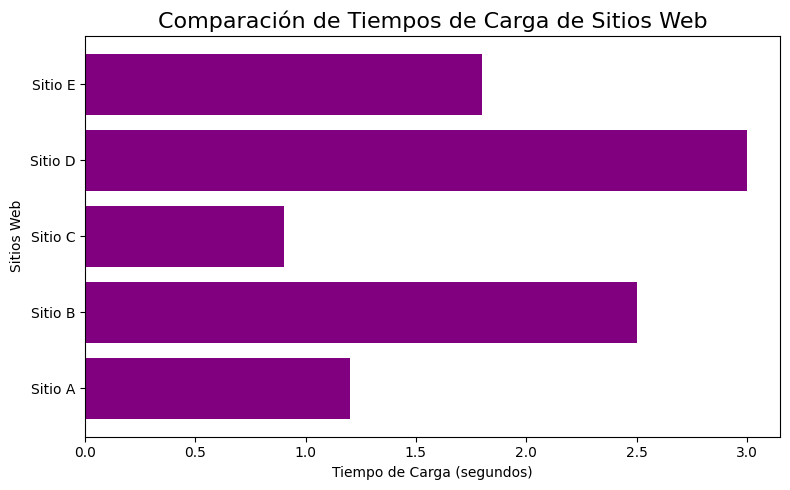

In [28]:
sitios = ['Sitio A', 'Sitio B', 'Sitio C', 'Sitio D', 'Sitio E']
tiempos = [1.2, 2.5, 0.9, 3.0, 1.8]

plt.figure(figsize=(8, 5))
plt.barh(sitios, tiempos, color='purple')

plt.title('Comparación de Tiempos de Carga de Sitios Web', fontsize=16)
plt.xlabel('Tiempo de Carga (segundos)')
plt.ylabel('Sitios Web')

plt.tight_layout()
plt.savefig('ej2_2_tiempos_carga.png', dpi=130)
plt.show()

**Interpretación:** Sitio C es el más rápido en cargar (0.9s) y Sitio D el más lento (3.0s) — candidato a optimización.

### 2.3 Relación entre horas de estudio y rendimiento académico

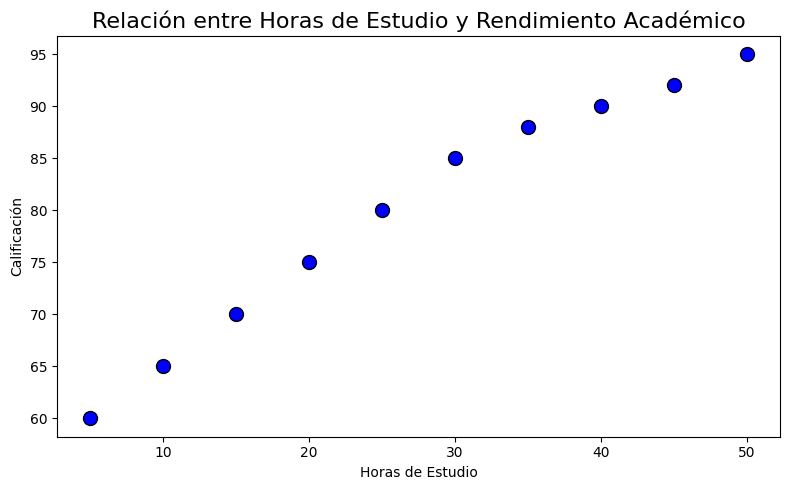

In [29]:
horas_estudio = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
calificaciones2 = [60, 65, 70, 75, 80, 85, 88, 90, 92, 95]

plt.figure(figsize=(8, 5))
plt.scatter(horas_estudio, calificaciones2, color='blue', s=100, edgecolor='black')

plt.title('Relación entre Horas de Estudio y Rendimiento Académico', fontsize=16)
plt.xlabel('Horas de Estudio')
plt.ylabel('Calificación')

plt.tight_layout()
plt.savefig('ej2_3_horas_estudio.png', dpi=130)
plt.show()

**Interpretación:** existe una correlación positiva casi lineal — a más horas de estudio, mejor es el rendimiento en los exámenes.

### 2.4 Distribución de salarios en tres departamentos distintos

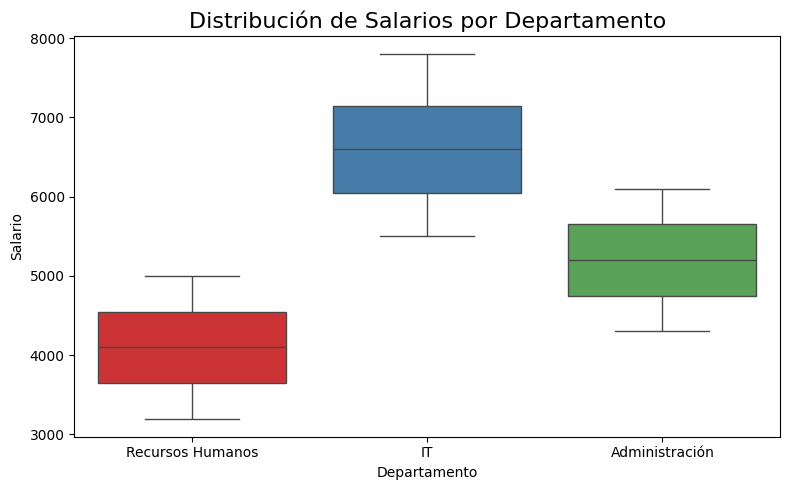

In [30]:
datos_salarios = {
    'Departamento': ['Recursos Humanos']*10 + ['IT']*10 + ['Administración']*10,
    'Salario': [3200, 3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800, 5000,
                5500, 5700, 6000, 6200, 6500, 6700, 7000, 7200, 7500, 7800,
                4300, 4500, 4700, 4900, 5100, 5300, 5500, 5700, 5900, 6100]
}
df_salarios = pd.DataFrame(datos_salarios)

plt.figure(figsize=(8, 5))
sns.boxplot(x='Departamento', y='Salario', hue='Departamento', data=df_salarios, palette='Set1', legend=False)

plt.title('Distribución de Salarios por Departamento', fontsize=16)
plt.xlabel('Departamento')
plt.ylabel('Salario')

plt.tight_layout()
plt.savefig('ej2_4_salarios.png', dpi=130)
plt.show()

**Interpretación:** IT tiene la mediana salarial más alta (~6,600) y mayor variabilidad; Recursos Humanos tiene la mediana más baja y la menor dispersión de salarios.